# Bias-Variance Tradeoff

The bias–variance tradeoff is frequently mentioned in statistics, econometrics, and machine learning. Though bearing the same name, the tradeoff between bias and variance of an estimator displays different mathematical implication in different contexts.

## 1 Bias-Variance Tradeoff in Econometrics

### Omitted Variable Bias


Consider the true data generating process is:
$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 +u$$

with $u \sim N(0,\sigma^2)$.

Our question is, what if we do not have variable $x_2$ in the data. In order word, what if we specified a wrong model - $y = \beta_0 + \beta_1 x_1 + u$?


In that case, we will run an OLS with an erroneous specification.

$$min_{\beta_0,\beta_1} \sum_i (y_i - \beta_0 - \beta_1 x_1)^2$$

The solution to which is:

$$\hat{\beta_0} = \bar{y}-\hat{\beta_1}\bar(x_1)$$
$$\hat{\beta_1} = \frac{\sum(y_i-\bar{y})(x_{1i}-\bar{x_1})}{\sum(x_{1i}-\bar{x_1})^2}$$

### Unbias

One important goal of statistical inference is to obtain an unbiased point estimator - i.e. when the sample changes (the unobservables change), the expected value of estimator is equal to the population parameter. In mathematical terms, this means

$$E_u[\hat{\beta}] = \beta$$

You can also treat $x_1 and x_2$ as random variables, but that will make the calculation more difficult.

Assume we are interested in estimating the slope parameter $\beta_1$. Let's see if $\hat{\beta_1}$ is an unbiased estimator.

$$
\begin{aligned}
    E_u[\hat{\beta_1}] &= \frac{1}{\sum (x_{1i}-\bar{x_1})^2}E_u[\sum y_i(x_{1i}-\bar{x_1})] - 0 \\
    &=\frac{1}{\sum (x_{1i}-\bar{x_1})^2}E_u[\sum (\beta_0 + \beta_1 x_{1i} + \beta-2 x_{2i} + u)(x_{1i}-\bar{x_1})] \\
    &=\frac{1}{\sum (x_{1i}-\bar{x_1})^2}E_u[\sum (\beta_1 x_{1i} + \beta_2 x_{2i})(x_{1i}-\bar{x_1})] \\
    &=\frac{\beta_1 E_u[\sum x_{1i}(x_{1i}-\bar{x_1})]}{\sum (x_i-\bar{x})^2} + \frac{E_u[\sum \beta_2 x_{2i}(x_{1i}-\bar{x_1})]}{\sum (x_{1i}-\bar{x_1})^2} \\
    &=\beta_1+\frac{\beta_2  \sum x_{2i}(x_{1i}-\bar{x_1})}{\sum (x_{1i}-\bar{x_1})^2}                      
\end{aligned}
$$

$\hat{\beta_1}$ is not an unbiased estimator if the sample covariance of $x_2$ and $x_1$ is not equal to 0, and $\beta_2$ is not equal to zero. (If you treat $x_1$ and $x_2$ as random variables, then it means $Cov(x_1,x_2)\neq 0$).

Hence, we can draw a conclusion that if an relevant variable is omitted from the model specification, and the omitted variable is correlated with the variable of interest, OLS estimators will be biased.

### Inflated Variance

One apparent solution to the omitted bias problem is to collect data on $x_2$ and include it in the model specification. This will make $\hat{\beta_1}$ unbiased.

But this remedy is based on the assumption that you already know the true data generating process, which is unlikely in real life - In real-life application, our starting point is a dataset, we can only "guess" how GOD designs the mechanism.

Alternatively, we can always add as many variables as possible into the specification. This method will act as a safety net and can be shown to yield unbiased estimators as long as the residuals satisfies Gauss-Markov Assumption 1: E[u|x]=0.

However, there is a **disadvantage** with this alternative method - adding more variables will inflate the variance of the estimator. To see this, let's consider the omitted variable example we used in the previous section

Using the misspecified model $y=\beta_0 + \beta_1 x_1 + u$, the variance of the estimator $\hat{\beta_1}$ is given by

$$Var_u(\hat{\beta_1}) = \frac{\sigma^2}{n Var(x_1)}$$

After adding $x_2$ into the model and rerun OLS, the variance of $\hat{\beta_1}^{more}$ becomes
$$Var_u(\hat{\beta_1}^{more}) = \frac{\sigma^2}{n Var(x_1)}\frac{1}{1-R_1^2}$$

where $R_1^2$ is the r-squared from regression $x_1$ on $x_2$

If $x_1$ and $x_2$ are not perfectly uncorrelated, $R_1^2>0$, and $\frac{1}{1-R_1^2}$ will be greater than 1, therefore "inflate" the first term in variance. This leads to $Var(\hat{\beta_1}^{more})>Var(\hat{\beta_1}^{less})$

> **Conclusion** \
Adding nonorthogonal (i.e. $Cov(x_{add},x_{rest})\neq 0$) variables into the model will increase the variance the of the old estimators.

## 2 Bias-Variance Tradeoff in Machine learning

Machine learning focus on the predicted value instead of individual coefficients. In this regard, let's focus on the bias and variance of the predicted value $\hat{y}$.

Since the goal of machine learning is to make the "best" predictions, we need to first set up a numerical "measure" to evaluate how "good" a prediction is. Such a measure is known as the **loss (or goal) function**.

A loss function closely related to OLS is the mean squared error loss.

$$MSE = E[(y - \hat{y})^2]$$

To obtain $\hat{y}$, the statistical convention is to estimate a sample version of the loss function, i.e.

$$\min_{\beta_0,\beta_1,...\beta_k} \frac{1}{N}\sum_i (y_i - \hat{y})^2$$

> Intuition: to minimize the loss function in the population, we should first minimize a similar loss function using the sample (the dataset we have).

Note that this minimization problem is exactly the same as an OLS regression. Hence the estimators and predictions will also be the same as OLS.

### Bias-Variance Decomposition of MSE

People soon became unsatisfied with the OLS type of estimation, and started seeking other ways to further minimize the population loss function - MSE.

> NOTE: Econometricians only care about the coefficients, therefore there is no need to pursue a better prediction (smaller loss) given that an unbiased and efficient estimator is already generated by OLS.

To achieve this goal, let's first gain a better understanding of the components of MSE. A decomposition can help us target the minimization effort at a specific part of the loss function.

$$
\begin{aligned}
    MSE &\equiv E_u[(y - \hat{y})^2]\\
        &= E[(f+u-\hat{y})^2] \\
        &= E[(f+u-\hat{y}+E[\hat{y}]-E[\hat{y}])^2] \\
        &= E[[(f-E[\hat{y}]) - (\hat{y}-E[\hat{y}])+u]^2] \\
        &= E[(f-E[\hat{y}])^2 + (\hat{y}-E[\hat{y}])^2 + u^2  - 2(f-E[\hat{y}])(\hat{y}-E[\hat{y}])) + 2(f-E[\hat{y}])u - 2 (\hat{y}-E[\hat{y}])u]
\end{aligned}
$$

By assumption $E[u] = 0$.

$$
\begin{aligned}
MSE &= E[(f-E(\hat{y}))^2] + E[(\hat{y}-E[\hat{y}])^2] + \sigma^2 \\
& = (f-E[\hat{y}])^2 + Var(\hat{y}) + \sigma^2 \\
&\equiv Bias(\hat{y})^2 + Var(\hat{y}) + \sigma^2
\end{aligned}
$$

> In statistics, the difference between the true parameter $\beta$ and the expected value of an estimator $E[\hat{\beta}]$ is called the bias of the estimator $\hat{\beta}$.

### Bias-Variance Tradeoff
The Bias-Variance decomposition of the MSE loss shows us that we can lower MSE by either reducing the bias of the prediction or by reducing the variance of the prediction - This is a trivial conclusion, one that can be drawn w/o math.

The question is rather: how can we reduce $Bias(\hat{y})$ or $Var(\hat{y})$?

### Solution 1 - add in new variables or high ordered terms
This idea comes from section 7.1, the omitted variable bias. By introducing possibly omitted variables, we can reduce the bias of the estimated coefficient, which leads to a reduced bias of prediction. To see this, we have

$$Bias(\hat{y}^{less}) = Bias(\hat{\beta_0}+\hat{\beta_1}x_1) \neq 0,$$

in the presence of an omitted variable $x_2$. After adding $x_2$ to the model,
$$Bias(\hat{y}^{more}) = Bias(\hat{\beta_0}^{more}+\hat{\beta_1}^{more}x_1 + \hat{\beta_2}^{more}x_2) = 0 $$
because when using the correct specification, OLS yields unbiased estimators.

But at the same time, $Var(\hat{y})$ will be higher due to two reasons: (1) $Var(\hat{y}^{more})$ has one more term inside the parenthesis than $Var(\hat{y}^{less})$; (2) Variance of the old parameters are higher if $x_2$ is non-orthogonal to the other variables.

Hence we have a tradeoff.

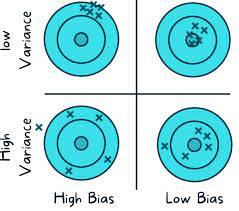

> Note that high-order polynomials are rarely used in econometrics because the starting point of econometrics should be a known economic theory - to prevent inflated variance, while also guarantee an unbiased estimator as mentioned in section 7.1. And in economic theories, high-order polynomials are rare.

**Graphical display of Tradeoff** - using train and test set.

Since adding additional varialbes to the model always decrease the MSE of the training sample, we need to create a test dataset to visualize the U-shaped MSE in the population. This involves a train/test splitting at the beginning of the analysis. Models will be only fitted to the train data, and the test data is left-out for model evaluation.

![bias-var](https://miro.medium.com/v2/resize:fit:1400/1*8nIJ2w5nRrdJQuLhtZ4L7g.png)

In graph, the y-axis shows the *sample* mean squared error - $\frac{1}{n}\sum_i (y_i-\hat{y})^2$. The red line displays the sample MSE using the test (validation) data as more polynomial terms are added into the model.

The blue line has nothing to do with the bias-variance tradeoff. It shows the sample MSE using train data. It decreases in the number of variables simply because you are enlarging the choice set.

### Solution 2: use other regression methods

Another solution to reduce MSE is by deliberately introducing bias with the hope that the variance will reduce at a higher rate. You can refer to the Ridge regression and the LASSO model. Regularization methods as such introduce bias into the regression solution that can reduce variance considerably relative to the ordinary least squares (OLS) solution. Although the OLS solution provides unbiased regression estimates, the lower variance solutions produced by regularization techniques provide superior MSE performance.

## 3 Exercise

Assume $y = 0 + 1x_1 + 2x_2 + 3 x_3 + u$, and $u\sim \mathcal{N}(0,1)$. We also know that $x_3\sim U(0,10)$ is independent of both $x_1$ and $x_2$, while $x_1$ and $x_2$ are correlated and satisfies a bivariate normal distribution with
$$\mu= \begin{bmatrix} 0 \\ 0\end{bmatrix}$$
and
$$\Sigma = \begin{bmatrix} 4&5 \\ 5&9 \end{bmatrix}$$

1. Generate a sample with 1000 observations. \
You can use `np.random.uniform` to generate $x_3$.\
use `np.random.multivariate_norm` to generate $x_1$ and $x_2$, \
use `np.random.randn` to generate u.

For reproducibility, add `np.random.seed(1)`.

In [13]:
import numpy as np
import pandas as pd


np.random.seed(1)
x3 = np.random.uniform(0,10,1000)
X12 = np.random.multivariate_normal([0,0],[[4,5],[5,9]],1000)
u = np.random.randn(1000)


df = pd.DataFrame({"x1":X12[:,0], "x2":X12[:,1],"x3":x3, "u":u})

df["y"] = 0 + 1*df["x1"]+ 2* df["x2"]+ 3*df["x3"]+df["u"]

df.head()

,x1,x2,x3,u,y
0,-1.063260,-2.308605,4.170220,0.296370,7.126559
1,-2.121900,-2.017276,7.203245,0.000008,15.453291
2,2.801666,4.252892,0.001144,-0.034211,11.276671
3,0.361978,0.154109,3.023326,-0.281499,9.458673
4,-0.120881,3.163531,1.467559,0.580178,11.189035


2. Regress y on x1, x2, and x3, and obtain the estimates.

In [14]:
import statsmodels.formula.api as smf
reg = smf.ols("y~x1 + x2 + x3", data = df)
res = reg.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.993
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                 4.490e+04
Date:                Wed, 11 Feb 2026   Prob (F-statistic):               0.00
Time:                        21:52:09   Log-Likelihood:                -1398.6
No. Observations:                1000   AIC:                             2805.
Df Residuals:                     996   BIC:                             2825.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0662      0.062     -1.064      0.2

3. If we omitted a key variable x2, what will happen to the estimated coefficient on x1? What about the coefficient on x3? What about the estimated constant?

In [15]:
reg2 = smf.ols("y~x1+x3", data=df)
res2 = reg2.fit()
print(res2.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.910
Model:                            OLS   Adj. R-squared:                  0.910
Method:                 Least Squares   F-statistic:                     5061.
Date:                Wed, 11 Feb 2026   Prob (F-statistic):               0.00
Time:                        21:52:11   Log-Likelihood:                -2649.9
No. Observations:                1000   AIC:                             5306.
Df Residuals:                     997   BIC:                             5321.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0363      0.217      0.167      0.8

4. If we omitted a key variable x3, what will happen to the estimated coefficient on x1? What about the standard error of $\hat{\beta_1}$

In [16]:
reg3 = smf.ols("y~x1+x2", data=df)
res3 = reg3.fit()
print(res3.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.418
Model:                            OLS   Adj. R-squared:                  0.417
Method:                 Least Squares   F-statistic:                     358.8
Date:                Wed, 11 Feb 2026   Prob (F-statistic):          4.27e-118
Time:                        21:52:14   Log-Likelihood:                -3584.7
No. Observations:                1000   AIC:                             7175.
Df Residuals:                     997   BIC:                             7190.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     14.9897      0.276     54.245      0.0

5. To avoid biased estimations, you regress y on x1, x2, x3, and $x_3^2$. Add the `x3sq` column to the df, and run a new regression. Comment on your findings.

In [17]:
df["x3sq"] = df["x3"]**2

In [19]:
reg4 = smf.ols("y~x1+x2+x3+x3sq", data=df)
res4 = reg4.fit()
print(res4.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.993
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                 3.366e+04
Date:                Wed, 11 Feb 2026   Prob (F-statistic):               0.00
Time:                        21:53:51   Log-Likelihood:                -1398.3
No. Observations:                1000   AIC:                             2807.
Df Residuals:                     995   BIC:                             2831.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1122      0.092     -1.218      0.2

In [21]:
res.bse

,0
Intercept,0.062243
x1,0.028554
x2,0.018871
x3,0.010786


6. What if we add in a variable x4 that is euqal to $x1+x2+x3$.

In [22]:
e = np.random.randn(1000)
df["x4"] = df["x1"] + df["x2"] +df["x3"]

In [24]:
reg5 = smf.ols("y~x1+x2+x3+x3+x4", df)
res5 = reg5.fit()
print(res5.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.993
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                 4.490e+04
Date:                Wed, 11 Feb 2026   Prob (F-statistic):               0.00
Time:                        21:55:44   Log-Likelihood:                -1398.6
No. Observations:                1000   AIC:                             2805.
Df Residuals:                     996   BIC:                             2825.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0662      0.062     -1.064      0.2